# CYGNSS Streamflow Modeling for Ungauged Basins (CSMUB)

## Feedforward Neural Network (FNN) Model

### About

This code

---


Author(s): Anna Valcarcel

Date of Creation: November 15, 2024

Last Updated: November 11, 2025

Version History:
*   v1.00:06 - Creating FNN architecture and running model. Modulating architecture and input parameters.
*   v1.07:09 - Added additional input parameters including land cover classification, soil texture, and terrain slope.

*   v2.00 - Re-running with new subset of all basins (605) after making delineation changes (see `CSMUB_v2_00`). 

## Importing Packages

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import classification_report

from tensorflow.python import keras
from tensorflow.keras import layers
from tensorflow.keras import backend as K
from keras import initializers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, SimpleRNN , Input, Flatten, LSTM, LeakyReLU
from tensorflow.keras import optimizers
from tensorflow.keras.optimizers import SGD, RMSprop, Nadam, Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.losses import Huber

## Define Filepaths and Open Station Masterfile


In [2]:
opened = []

masterlist = '/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/RESULTS/ALL_STATIONS_ALL_DAYS_COMBINED.csv'

# Load the master list of stations
total_df = pd.read_csv(masterlist)

/tmp/ipykernel_392968/1724744278.py:6: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  total_df = pd.read_csv(masterlist)


In [3]:
total_df = total_df[total_df['Q'] != -999]
print(f"Remaining rows: {len(total_df)}")

Remaining rows: 844768


In [4]:
print("Loaded ", len(total_df['grdc_no'].unique()), " stations.")

Loaded  563  stations.


## Save Subset for Training

In [5]:
print(total_df.columns)

Index(['Date', 'grdc_no', 'river', 'station', 'country', 'lat', 'long', 'area',
       'area_delin', 'altitude', 'Q', 'SWE', 'SWE_scaled', 'r2', 'P',
       'avg_slope', 'max_slope', 'LC_1', 'LC_2', 'LC_3', 'LC_4', 'LC_5',
       'LC_6', 'LC_7', 'LC_8', 'LC_9', 'LC_10', 'LC_11', 'LC_12', 'LC_13',
       'LC_14', 'LC_15', 'LC_16', 'LC_17', 'LC_18', 'LC_19', 'LC_20', 'ST_1',
       'ST_2', 'ST_3', 'ST_4', 'ST_5', 'ST_6', 'ST_7', 'ST_8', 'ST_9', 'ST_10',
       'ST_11', 'ST_12', 'ST_13', 'ST_14', 'ST_15', 'ST_16'],
      dtype='object')


In [6]:
training_df = total_df.drop(['Date', 'grdc_no', 'river', 'station', 'country', 'long', 'area',
       'altitude', 'Q', 'SWE','r2',], axis=1)
test_df = total_df['Q']

print(training_df.columns)
print(test_df)

Index(['lat', 'area_delin', 'SWE_scaled', 'P', 'avg_slope', 'max_slope',
       'LC_1', 'LC_2', 'LC_3', 'LC_4', 'LC_5', 'LC_6', 'LC_7', 'LC_8', 'LC_9',
       'LC_10', 'LC_11', 'LC_12', 'LC_13', 'LC_14', 'LC_15', 'LC_16', 'LC_17',
       'LC_18', 'LC_19', 'LC_20', 'ST_1', 'ST_2', 'ST_3', 'ST_4', 'ST_5',
       'ST_6', 'ST_7', 'ST_8', 'ST_9', 'ST_10', 'ST_11', 'ST_12', 'ST_13',
       'ST_14', 'ST_15', 'ST_16'],
      dtype='object')
0         26.393
1         27.602
2         26.674
3         26.687
4         26.988
           ...  
892793    11.757
892794    11.458
892795     9.106
892796     7.894
892797     7.240
Name: Q, Length: 844768, dtype: float64


In [7]:
# ----------------------------
# Preserve metadata (NOT for training)
# ----------------------------
metadata = total_df[['Date', 'grdc_no']].copy()

In [24]:
# ----------------------------
# Create feature matrix and target
# ----------------------------
X_df = total_df.drop(
    columns=[
        'Date', 'grdc_no', 'river', 'station', 'country',
        'long', 'area', 'altitude',
        'Q', 'SWE', 'r2'
    ]
)

y_df = total_df['Q']

print(X_df.columns)

X = X_df.to_numpy()
y = y_df.to_numpy()

Index(['lat', 'area_delin', 'SWE_scaled', 'P', 'avg_slope', 'max_slope',
       'LC_1', 'LC_2', 'LC_3', 'LC_4', 'LC_5', 'LC_6', 'LC_7', 'LC_8', 'LC_9',
       'LC_10', 'LC_11', 'LC_12', 'LC_13', 'LC_14', 'LC_15', 'LC_16', 'LC_17',
       'LC_18', 'LC_19', 'LC_20', 'ST_1', 'ST_2', 'ST_3', 'ST_4', 'ST_5',
       'ST_6', 'ST_7', 'ST_8', 'ST_9', 'ST_10', 'ST_11', 'ST_12', 'ST_13',
       'ST_14', 'ST_15', 'ST_16'],
      dtype='object')


## FNN Setup

In [25]:
# Step 1: Replace zeros with a small value
X[X == 0] = 1e-9

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1))

In [26]:
X_train, X_test, y_train, y_test, meta_train, meta_test = train_test_split(
    X_scaled,
    y_scaled,
    metadata,
    test_size=0.2,
    random_state=42
)

## Run FNN

In [27]:
# Define the model
model = Sequential([
    Dense(512, input_dim=42, activation='relu'),
    # Dense(256, activation='leaky_relu'),
    # Dropout(0.2),
    Dense(128, activation='relu'),
    Dropout(0.2),
    # Dense(64, activation='leaky_relu'),
    # Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')  # Linear activation for regression
])

# Compile the model
model.compile(optimizer=Nadam(learning_rate=1e-3), loss=Huber(delta=0.1), metrics=['accuracy','mae','mse','r2_score'])

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10)

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=130,  # High epochs with early stopping
    batch_size=64,
    validation_data=(X_test, y_test),
    verbose=1
    # callbacks=[early_stopping, lr_scheduler]
)

/global/home/users/arvalcarcel/.local/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/130
10560/10560 ━━━━━━━━━━━━━━━━━━━━ 33s 3ms/step - accuracy: 0.0995 - loss: 8.2736e-05 - mae: 0.0041 - mse: 2.2866e-04 - r2_score: 0.7829 - val_accuracy: 0.0987 - val_loss: 7.8146e-05 - val_mae: 0.0096 - val_mse: 1.7298e-04 - val_r2_score: 0.8315
Epoch 2/130
10560/10560 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - accuracy: 0.0997 - loss: 4.8376e-05 - mae: 0.0028 - mse: 1.1967e-04 - r2_score: 0.8904 - val_accuracy: 0.0987 - val_loss: 9.4671e-05 - val_mae: 0.0112 - val_mse: 2.0073e-04 - val_r2_score: 0.8045
Epoch 3/130
10560/10560 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - accuracy: 0.0994 - loss: 4.3688e-05 - mae: 0.0027 - mse: 1.0593e-04 - r2_score: 0.8996 - val_accuracy: 0.0987 - val_loss: 8.9344e-05 - val_mae: 0.0112 - val_mse: 1.9235e-04 - val_r2_score: 0.8127
Epoch 4/130
10560/10560 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - accuracy: 0.0986 - loss: 4.0684e-05 - mae: 0.0026 - mse: 9.8664e-05 - r2_score: 0.9044 - val_accuracy: 0.0987 - val_loss: 1.0322e-04 - val_mae: 0.0124 - val_mse: 2.1848e-04

In [28]:
model.save('CSMUB_FNN_DAILY_V2_02_12182025.keras')

## Analyze FNN Results

In [29]:
# Step 7: Evaluate
test_loss = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}")

5280/5280 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.0987 - loss: 5.5287e-04 - mae: 0.0328 - mse: 0.0011 - r2_score: -0.0885
Test Loss: [0.0005523586878553033, 0.09871325641870499, 0.03278975188732147, 0.0011115440865978599, -0.08251476287841797]


In [30]:
# Step 8: Predict
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)

y_test_scaled = y_test
y_test = scaler_y.inverse_transform(y_test)

results = meta_test.copy()
results['Q_true'] = y_test.flatten()
results['Q_pred'] = y_pred.flatten()

5280/5280 ━━━━━━━━━━━━━━━━━━━━ 5s 934us/step


In [31]:
def nse(predictions, targets):
    return 1 - (np.sum((targets - predictions) ** 2) / np.sum((targets - np.mean(targets)) ** 2))

nse(y_pred, y_test)

-0.08251380999105029

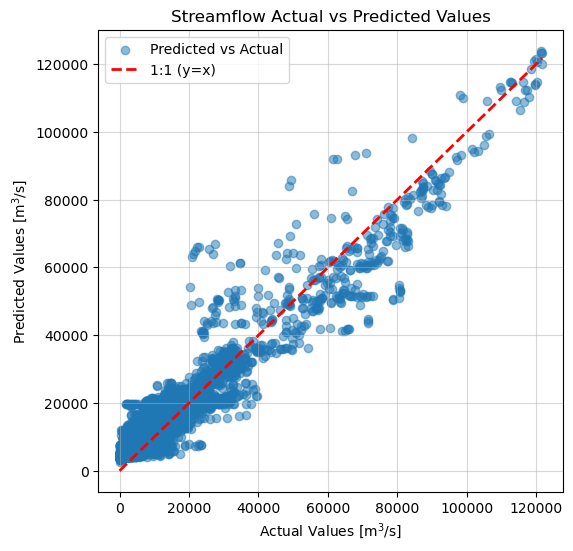

In [32]:
# Step 2: Create the scatter plot
plt.figure(figsize=(6,6))
plt.scatter(results['Q_true'], results['Q_pred'], alpha=0.5, label="Predicted vs Actual")
plt.plot([0, y.max()], [0, y.max()], 'r--', label='1:1 (y=x)', linewidth=2)

# Step 3: Add labels, title, and legend
plt.title("Streamflow Actual vs Predicted Values")
plt.xlabel("Actual Values [m${^3}$/s]")
plt.ylabel("Predicted Values [m${^3}$/s]")
plt.legend()
# plt.xlim(0,25000)
# plt.ylim(0,25000)
plt.grid(alpha=0.5)

# Step 4: Show the plot
plt.show()

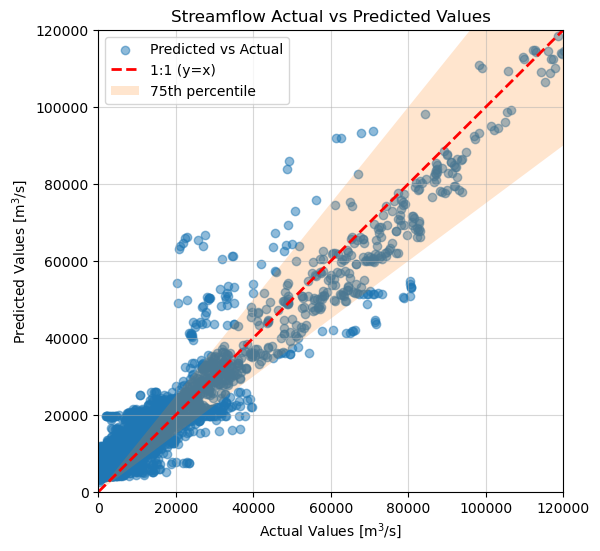

In [33]:
error = 0.25*np.arange(y.min(), y.max(),100)
y_err = np.arange(y.min(), y.max(),100)

# Step 2: Create the scatter plot
plt.figure(figsize=(6,6))
plt.scatter(results['Q_true'], results['Q_pred'], alpha=0.5, label="Predicted vs Actual")
plt.plot([0, y.max()], [0, y.max()], 'r--', label='1:1 (y=x)', linewidth=2)
plt.fill_between(y_err, y_err-error, y_err+error,alpha=0.2,label='75th percentile')

# Step 3: Add labels, title, and legend
plt.title("Streamflow Actual vs Predicted Values")
plt.xlabel("Actual Values [m${^3}$/s]")
plt.ylabel("Predicted Values [m${^3}$/s]")
plt.legend(loc='upper left')
plt.xlim(0,120000)
plt.ylim(0,120000)
plt.grid(alpha=0.5)

# Step 4: Show the plot
plt.show()

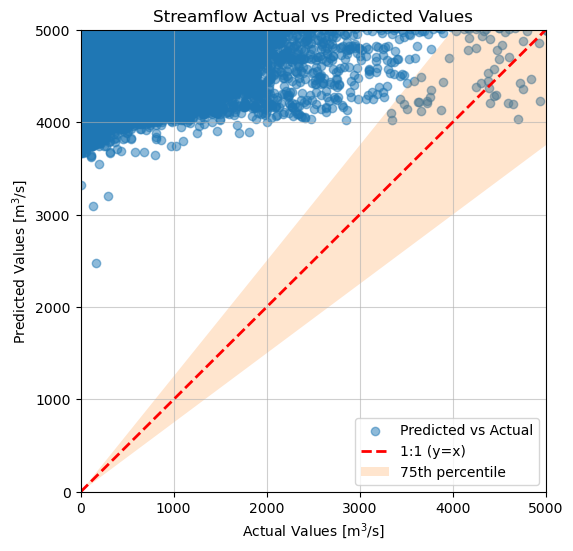

In [34]:
plt.figure(figsize=(6,6))
plt.scatter(results['Q_true'], results['Q_pred'], alpha=0.5, label="Predicted vs Actual")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='1:1 (y=x)', linewidth=2)
plt.fill_between(y_err, y_err-error, y_err+error,alpha=0.2,label='75th percentile')

# Step 3: Add labels, title, and legend
plt.title("Streamflow Actual vs Predicted Values")
plt.xlabel("Actual Values [m${^3}$/s]")
plt.ylabel("Predicted Values [m${^3}$/s]")
plt.legend()
plt.xlim(0,5000)
plt.ylim(0,5000)
plt.grid(alpha=0.6)

# Step 4: Show the plot
plt.show()

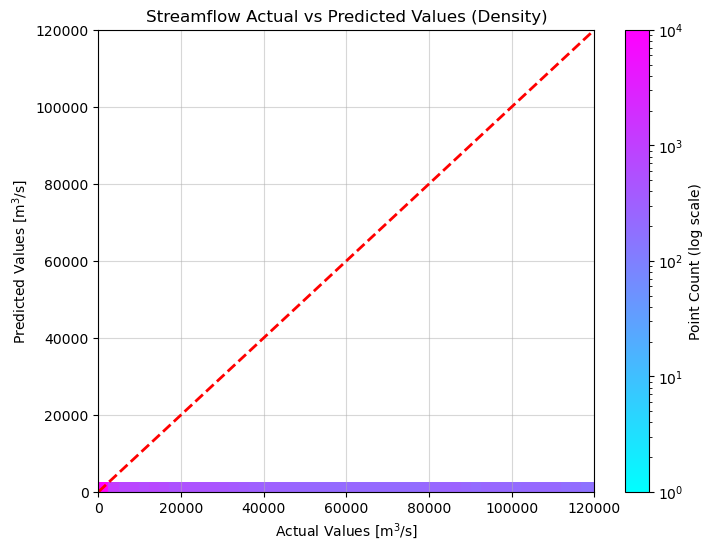

In [33]:
from matplotlib.colors import LogNorm

plt.figure(figsize=(8, 6))

h = plt.hist2d(
    results['Q_true'],
    results['Q_pred'],
    bins=50,
    range=[[0, y.max()], [0, y.max()]],
    norm=LogNorm(vmin=1, vmax=1e4),  # manual scaling
    cmap='cool'                  # reversed plasma
)

cbar = plt.colorbar(h[3])
cbar.set_label("Point Count (log scale)")

plt.plot([0, y.max()], [0, y.max()], 'r--', linewidth=2)
plt.xlim(0,120000)
plt.ylim(0,120000)
plt.title("Streamflow Actual vs Predicted Values (Density)")
plt.xlabel("Actual Values [m$^3$/s]")
plt.ylabel("Predicted Values [m$^3$/s]")
plt.grid(alpha=0.5)

plt.show()

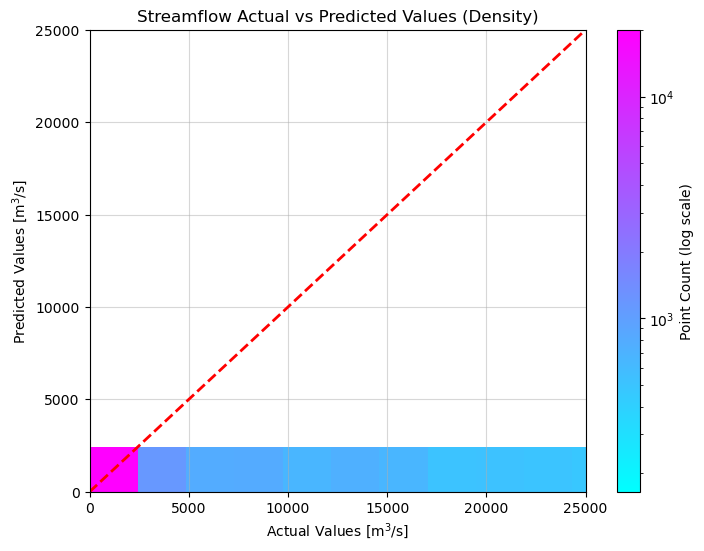

In [34]:
from matplotlib.colors import LogNorm

plt.figure(figsize=(8, 6))

h = plt.hist2d(
    results['Q_true'],
    results['Q_pred'],
    bins=50,
    range=[[0, y.max()], [0, y.max()]],
    norm=LogNorm(),
    cmap = 'cool' 
)

cbar = plt.colorbar(h[3])
cbar.set_label("Point Count (log scale)")

plt.plot([0, y.max()], [0, y.max()], 'r--', linewidth=2)
plt.xlim(0,25000)
plt.ylim(0,25000)
plt.title("Streamflow Actual vs Predicted Values (Density)")
plt.xlabel("Actual Values [m$^3$/s]")
plt.ylabel("Predicted Values [m$^3$/s]")
plt.grid(alpha=0.5)

plt.show()


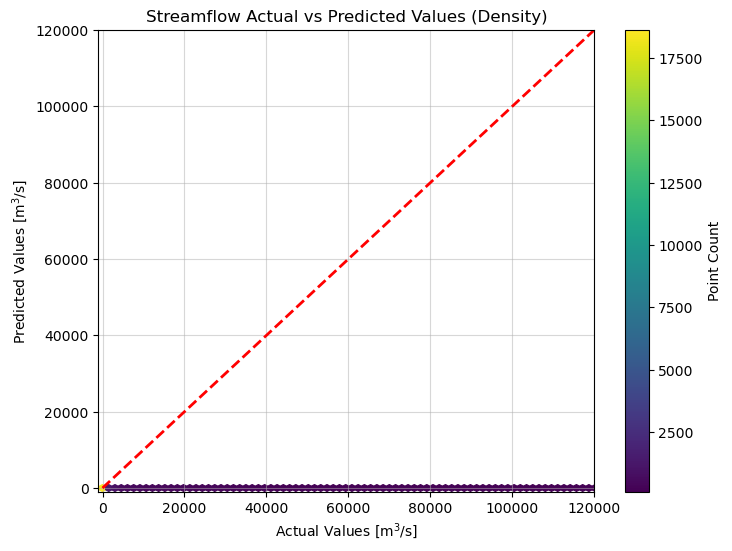

In [35]:
plt.figure(figsize=(8, 6))

hb = plt.hexbin(
    results['Q_true'],
    results['Q_pred'],
    gridsize=80,
    extent=[0, y.max(), 0, y.max()],
    mincnt=1
)

cbar = plt.colorbar(hb)
cbar.set_label("Point Count")

plt.plot([0, y.max()], [0, y.max()], 'r--', linewidth=2)
plt.xlim(-1000,120000)
plt.ylim(-1000,120000)
plt.xlabel("Actual Values [m$^3$/s]")
plt.ylabel("Predicted Values [m$^3$/s]")
plt.title("Streamflow Actual vs Predicted Values (Density)")
plt.grid(alpha=0.5)

plt.show()

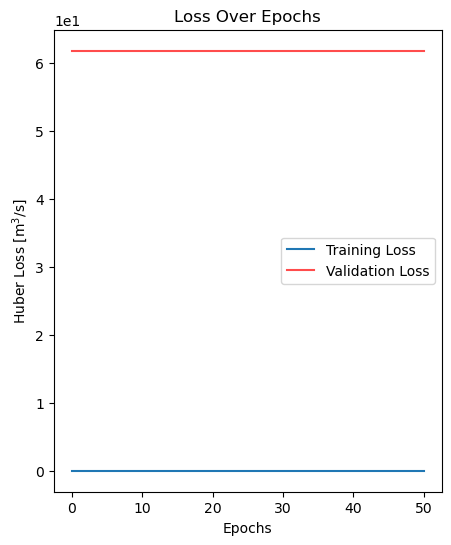

In [36]:
# Plot Loss 
plt.figure(figsize=(5,6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss',color='r',alpha=0.7)
plt.xlabel('Epochs')
plt.ylabel('Huber Loss [m${^3}$/s]')
plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
plt.title('Loss Over Epochs')
# plt.ylim(0.00001, 0.0002)
plt.legend()
plt.show()

/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


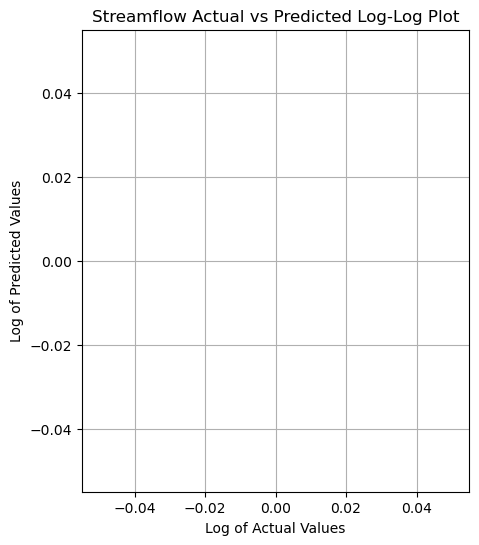

In [37]:
# Create the log-log plot

xlog = np.log(results['Q_true'])
ylog = np.log(results['Q_pred'])

plt.figure(figsize=(5,6))
plt.scatter(xlog, ylog)
# Add labels and title
plt.xlabel('Log of Actual Values')
plt.ylabel('Log of Predicted Values')
plt.title('Streamflow Actual vs Predicted Log-Log Plot')

# Customize gridlines (optional)
plt.grid(True, which="both", ls="-")

# Show the plot
plt.show()

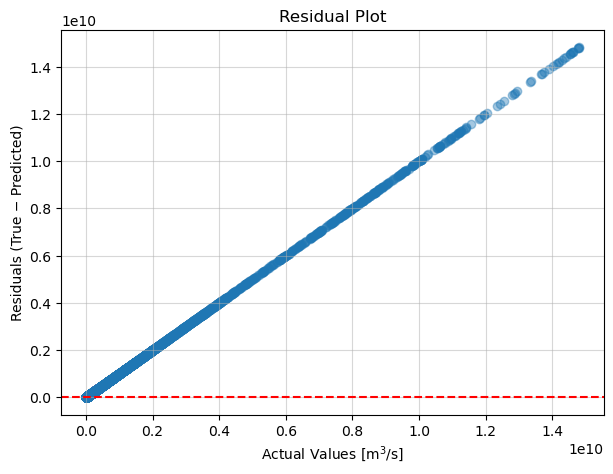

In [38]:
plt.figure(figsize=(7, 5))
residuals = y_test - y_pred
plt.scatter(y_test, residuals, alpha=0.4)
plt.axhline(0, color='red', linestyle='--')

plt.xlabel("Actual Values [m$^3$/s]")
plt.ylabel("Residuals (True − Predicted)")
plt.title("Residual Plot")
plt.grid(alpha=0.5)

plt.show()

In [39]:
# # Aggregate to station level
# station_summary = total_df.groupby('grdc_no').agg(
#     SWE_mean=('SWE_scaled', 'mean'),
#     SWE_min=('SWE_scaled', 'min'),
#     SWE_max=('SWE_scaled', 'max'),
#     Q_mean=('Q', 'mean'),
#     Q_min=('Q', 'min'),
#     Q_max=('Q', 'max')
# ).reset_index()

# yerr_lower = station_summary['Q_mean'] - station_summary['Q_min']
# yerr_upper = station_summary['Q_max'] - station_summary['Q_mean']

# yerr = [yerr_lower, yerr_upper]


# plt.figure(figsize=(10,6))

# plt.errorbar(
#     station_summary['SWE_mean'],
#     station_summary['Q_mean'],
#     yerr=yerr,
#     fmt='o',
#     markersize=6,
#     alpha=0.7,
#     elinewidth=1,
#     capsize=3
# )

# plt.title('Station-Averaged Streamflow vs Surface Water Extent')
# plt.xlabel('Surface Water Extent Area [km$^2$]')
# plt.ylabel('Streamflow [m$^3$/s]')
# plt.grid(True)
# plt.tight_layout()
# plt.show()

In [40]:
# First digit of station number → continent code
station_summary['continent_code'] = (
    station_summary['grdc_no']
    .astype(str)
    .str[0]
    .astype(int)
)

continent_labels = {
    1: 'Africa',
    2: 'Asia',
    3: 'South America',
    4: 'North / Central America',
    5: 'Australia'
}

continent_colors = {
    1: 'tab:brown',
    2: 'tab:orange',
    3: 'tab:green',
    4: 'tab:blue',
    5: 'tab:purple'
}

yerr_lower = station_summary['Q_mean'] - station_summary['Q_min']
yerr_upper = station_summary['Q_max'] - station_summary['Q_mean']
yerr = [yerr_lower, yerr_upper]

plt.figure(figsize=(10,6))

for code, label in continent_labels.items():
    subset = station_summary[
        (station_summary['continent_code'] == code) &
        (subset := station_summary)['Q_min'].gt(0)
    ]
    
    # Y error bars (Q range)
    yerr_sub = [
        subset['Q_mean'] - subset['Q_min'],
        subset['Q_max'] - subset['Q_mean']
    ]
    
    # X error bars (SWE range)
    xerr_sub = [
        subset['SWE_mean'] - subset['SWE_min'],
        subset['SWE_max'] - subset['SWE_mean']
    ]
    
    plt.errorbar(
        subset['SWE_mean'],
        subset['Q_mean'],
        xerr=xerr_sub,          # 🔥 X ERROR BARS
        yerr=yerr_sub,
        fmt='o',
        markersize=6,
        alpha=0.75,
        elinewidth=1,
        capsize=3,
        color=continent_colors[code],
        label=label
    )

plt.title('Station-Averaged Streamflow vs Surface Water Extent')
plt.xlabel('Surface Water Extent Area [km$^2$]')
plt.ylabel('Streamflow [m$^3$/s]')
plt.legend(title='Continent', frameon=True)
plt.grid(True)
plt.tight_layout()
plt.show()

NameError: name 'station_summary' is not defined

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, (code, label) in zip(axes, continent_labels.items()):
    subset = station_summary[
        (station_summary['continent_code'] == code) &
        (station_summary['Q_min'] > 0) &
        (station_summary['SWE_min'] >= 0)
    ]
    
    # Y-axis error bars (Q range)
    yerr_sub = [
        subset['Q_mean'] - subset['Q_min'],
        subset['Q_max'] - subset['Q_mean']
    ]
    
    # X-axis error bars (SWE range)
    xerr_sub = [
        subset['SWE_mean'] - subset['SWE_min'],
        subset['SWE_max'] - subset['SWE_mean']
    ]
    
    ax.errorbar(
        subset['SWE_mean'],
        subset['Q_mean'],
        xerr=xerr_sub,          # 🔥 horizontal error bars
        yerr=yerr_sub,
        fmt='o',
        markersize=6,
        alpha=0.75,
        elinewidth=1,
        capsize=3,
        color=continent_colors[code]
    )
    
    ax.set_title(label)
    ax.grid(True, alpha=0.5)

# Remove unused subplot (6th panel)
axes[-1].axis('off')

# Shared labels
fig.supxlabel('Surface Water Extent Area [km$^2$]')
fig.supylabel('Streamflow [m$^3$/s]')

fig.suptitle(
    'Station-Averaged Streamflow vs Surface Water Extent by Continent',
    fontsize=16
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
plt.figure(figsize=(10,6))

for code, label in continent_labels.items():
    subset = station_summary[
        (station_summary['continent_code'] == code) &
        (subset := station_summary)['Q_min'].gt(0)
    ]
    
    # Y error bars (Q range)
    yerr_sub = [
        subset['Q_mean'] - subset['Q_min'],
        subset['Q_max'] - subset['Q_mean']
    ]
    
    # X error bars (SWE range)
    xerr_sub = [
        subset['SWE_mean'] - subset['SWE_min'],
        subset['SWE_max'] - subset['SWE_mean']
    ]
    
    plt.errorbar(
        subset['SWE_mean'],
        subset['Q_mean'],
        xerr=xerr_sub,          # 🔥 X ERROR BARS
        yerr=yerr_sub,
        fmt='o',
        markersize=6,
        alpha=0.75,
        elinewidth=1,
        capsize=3,
        color=continent_colors[code],
        label=label
    )

plt.yscale('log')  # 🔥 LOG SCALE HERE
plt.xscale('log')
plt.title('Station-Averaged Streamflow vs Surface Water Extent - Log Scale')
plt.xlabel('Surface Water Extent Area [km$^2$]')
plt.ylabel('Streamflow [m$^3$/s] (log scale)')
plt.legend(title='Continent', frameon=True)
plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

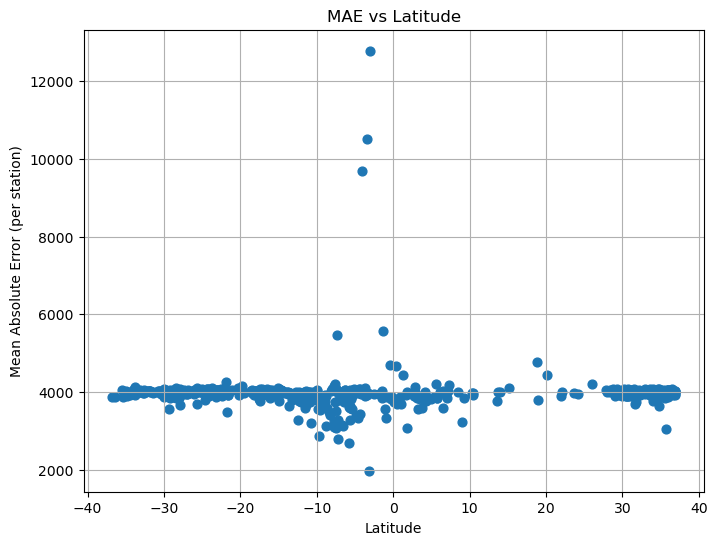

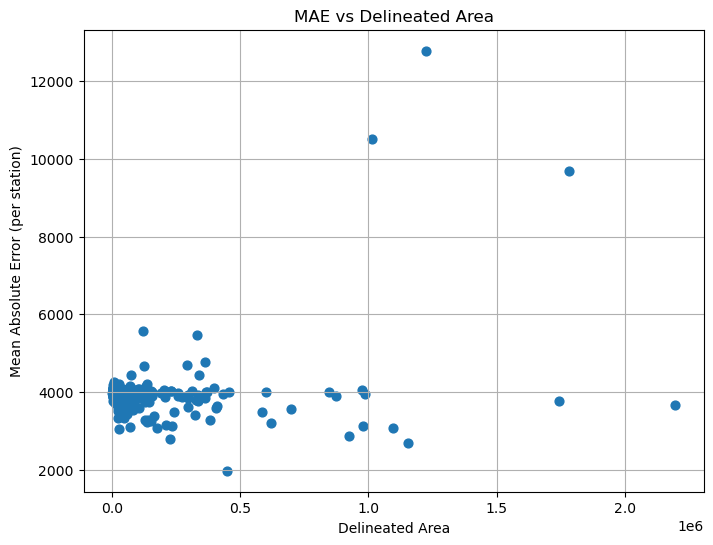

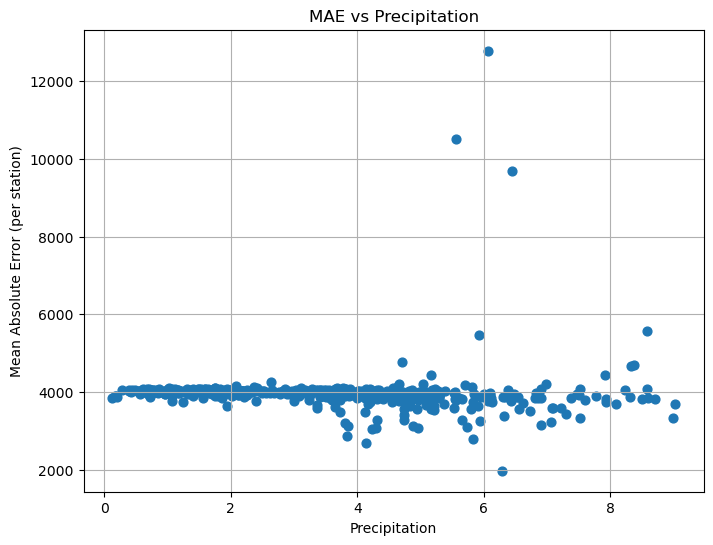

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Make sure y_test_unscaled and y_pred are unscaled
errors = np.abs(y_pred - y_test).reshape(-1)

# Add errors and meta-data to a DataFrame
error_df = meta_test.copy()
error_df['error'] = errors

# Include the features you want to plot
X_unscaled = scaler_X.inverse_transform(X_test)
error_df['lat'] = X_unscaled[:, 0]          # column 0
error_df['area_delin'] = X_unscaled[:, 1]   # column 1
error_df['P'] = X_unscaled[:, 3]            # column 3

# Aggregate by station (grdc_no)
station_error = error_df.groupby('grdc_no').agg({
    'error': 'mean',       # mean absolute error per station
    'lat': 'first',        # constant per station
    'area_delin': 'first', # constant per station
    'P': 'mean'            # average P per station
}).reset_index()

# Plot function
def plot_feature_vs_station_error(df, feature_col, feature_name):
    plt.figure(figsize=(8,6))
    plt.scatter(df[feature_col], df['error'], s=40)
    plt.xlabel(feature_name)
    plt.ylabel('Mean Absolute Error (per station)')
    plt.title(f'MAE vs {feature_name}')
    plt.grid(True)
    plt.show()

# Plots
plot_feature_vs_station_error(station_error, 'lat', 'Latitude')
plot_feature_vs_station_error(station_error, 'area_delin', 'Delineated Area')
plot_feature_vs_station_error(station_error, 'P', 'Precipitation')

In [37]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter

# -------------------------------
# Unscale predictions and targets
# -------------------------------
y_pred_unscaled = scaler_y.inverse_transform(
    y_pred.reshape(-1, 1)
).ravel()

y_test_unscaled = scaler_y.inverse_transform(
    y_test.reshape(-1, 1)
).ravel()

# -------------------------------
# Absolute error in physical units
# -------------------------------
errors = np.abs(y_pred_unscaled - y_test_unscaled)

# -------------------------------
# Build error DataFrame
# -------------------------------
error_df = meta_test.copy()
error_df['error'] = errors
error_df['Q_obs'] = y_test_unscaled

# -------------------------------
# 🔴 THIS STEP WAS MISSING
# Aggregate per station
# -------------------------------
station_error = error_df.groupby('grdc_no').agg({
    'error': 'mean',        # MAE per station
    'Q_obs': 'mean',        # mean observed Q per station
    'lat': 'first',
    'area_delin': 'first',
    'P': 'mean',
    'max_slope': 'first'
}).reset_index()

# -------------------------------
# Normalized MAE (dimensionless)
# -------------------------------
station_error['nMAE'] = station_error['error'] / station_error['Q_obs']

# # Optional: remove very low-flow stations
# station_error = station_error[station_error['Q_obs'] > 0.1]

# -------------------------------
# Helper formatting functions
# -------------------------------
def format_bin_label(interval):
    left = interval.left
    right = interval.right
    return f"[{left:.1e}, {right:.1e})"

def format_bin_label_multiline_int(interval):
    left = int(interval.left)
    right = int(interval.right)
    return f"[{left:,}\n{right:,})"

# -------------------------------
# Plotting function (normalized MAE)
# -------------------------------
def plot_feature_vs_station_error_colored(df, feature_col, feature_name, bins):

    plt.figure(figsize=(10, 6))

    df = df.copy()
    df['feature_bin'] = pd.cut(df[feature_col], bins=bins, right=False)

    bin_error = df.groupby('feature_bin', observed=True)['nMAE'].mean()
    bin_counts = df.groupby('feature_bin', observed=True)['nMAE'].count()

    colors = plt.cm.cool(bin_counts / bin_counts.max())

    x = np.arange(len(bin_error))
    bars = plt.bar(x, bin_error.values, color=colors, width=0.8)

    # Custom x-axis labels
    if feature_col == 'area_delin':
        labels = [format_bin_label_multiline_int(i) for i in bin_error.index]
    else:
        labels = [str(i) for i in bin_error.index]

    plt.xticks(x, labels)

    # Annotate counts
    for bar, count in zip(bars, bin_counts):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            str(count),
            ha='center',
            va='bottom',
            fontsize=10
        )

    plt.xlabel(feature_name)
    plt.ylabel('Normalized MAE (MAE / mean Q)')
    plt.title(f'Normalized MAE vs {feature_name}')

    sm = mpl.cm.ScalarMappable(
        cmap='cool',
        norm=mpl.colors.Normalize(
            vmin=bin_counts.min(),
            vmax=bin_counts.max()
        )
    )
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=plt.gca())
    cbar.set_label('Number of stations per bin')

    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

# -------------------------------
# Custom bin edges
# -------------------------------
lat_bins   = np.arange(-40, 40, 10)
area_bins  = np.arange(1e4, 5.5e5, 5e4)
P_bins     = np.arange(0, 11, 1)
slope_bins = np.arange(-90, 90, 10)

# -------------------------------
# Plot
# -------------------------------
plot_feature_vs_station_error_colored(
    station_error, 'lat', 'Latitude [deg]', lat_bins
)

plot_feature_vs_station_error_colored(
    station_error, 'area_delin', 'Basin Area [km$^2$]', area_bins
)

plot_feature_vs_station_error_colored(
    station_error, 'P', 'Precipitation [mm/day]', P_bins
)

plot_feature_vs_station_error_colored(
    station_error, 'max_slope', 'Max. Slope [deg]', slope_bins
)


KeyError: "Column(s) ['P', 'area_delin', 'lat', 'max_slope'] do not exist"

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.ticker import FuncFormatter

# Make sure y_test_unscaled and y_pred are unscaled
errors = np.abs(y_pred - y_test).reshape(-1)

# Add errors and meta-data to a DataFrame
error_df = meta_test.copy()
error_df['error'] = errors

# Include the features you want to plot
X_unscaled = scaler_X.inverse_transform(X_test)
error_df['lat'] = X_unscaled[:, 0]          # column 0
error_df['area_delin'] = X_unscaled[:, 1]   # column 1
error_df['P'] = X_unscaled[:, 3]            # column 3
error_df['max_slope'] = X_unscaled[:, 5] 

# Aggregate by station (grdc_no)
station_error = error_df.groupby('grdc_no').agg({
    'error': 'mean',       # mean absolute error per station
    'lat': 'first',        # constant per station
    'area_delin': 'first', # constant per station
    'P': 'mean',            # average P per station
    'max_slope': 'first'
}).reset_index()

def format_bin_label(interval):
    """Format pandas Interval nicely in scientific notation."""
    left = interval.left
    right = interval.right
    return f"[{left:.1e}, {right:.1e})"

def plot_feature_vs_station_error_colored(df, feature_col, feature_name, bins):
    plt.figure(figsize=(10,6))
    
    df['feature_bin'] = pd.cut(df[feature_col], bins=bins, right=False)

    bin_error = df.groupby('feature_bin', observed=True)['error'].mean()
    bin_counts = df.groupby('feature_bin', observed=True)['error'].count()

    colors = plt.cm.cool(bin_counts / bin_counts.max())

    x = np.arange(len(bin_error))
    bars = plt.bar(x, bin_error.values, color=colors, width=0.8)
    
    def format_bin_label_multiline_int(interval):
        left = int(interval.left)
        right = int(interval.right)
        return f"[{left:,}\n{right:,})"

    # --- Custom tick labels ---
    if feature_col == 'area_delin':
        labels = [format_bin_label_multiline_int(i) for i in bin_error.index]
    else:
        labels = [str(i) for i in bin_error.index]
    
    plt.xticks(x, labels)

    # Add counts on bars
    for bar, count in zip(bars, bin_counts):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 str(count), ha='center', va='bottom', fontsize=10)

    plt.xlabel(feature_name)
    plt.ylabel('Mean Absolute Error [m$^3$/s]')
    plt.title(f'MAE vs {feature_name}')

    sm = mpl.cm.ScalarMappable(
        cmap='cool',
        norm=mpl.colors.Normalize(vmin=bin_counts.min(), vmax=bin_counts.max())
    )
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=plt.gca())
    cbar.set_label('Number of stations per bin')

    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()


# --- Custom bin edges ---
lat_bins = np.arange(-40, 40, 10)
area_bins = np.arange(1e4, 5.5e5, 5e4)
P_bins = np.arange(0, 11, 1)
slope_bins = np.arange(-90, 90, 10)

# Plot
plot_feature_vs_station_error_colored(station_error, 'lat', 'Latitude [deg]', lat_bins)
plot_feature_vs_station_error_colored(station_error, 'area_delin', 'Basin Area [km$^2$]', area_bins)
plot_feature_vs_station_error_colored(station_error, 'P', 'Precipitation [mm/day]', P_bins)
plot_feature_vs_station_error_colored(station_error, 'max_slope', 'Max. Slope [deg]', slope_bins)

## Recreate Timeseries

In [ ]:
# # Re-create timeseries
# station_no = total_df['grdc_no'].unique()
# freq_stations = total_df['grdc_no'].value_counts()

# N = 100
# rand_stations = np.random.choice(station_no, size=N, replace=False)
# print(rand_stations[0])

In [38]:
import numpy as np
import pandas as pd
import matplotlib.ticker as ticker
import os

# Re-create timeseries
station_no = total_df['grdc_no'].unique()

# Output directory for CSVs
csv_outdir = (
    '/global/scratch/users/cgerlein/fc_ecohydrology_scratch/'
    'CSMUB/RESULTS/TIMESERIES/DAILY_PREDICTED/CSV/'
)
os.makedirs(csv_outdir, exist_ok=True)

# Optional: store MAPE per station
mape_by_station = {}

for i in range(0, len(station_no)):

    test_station_num = int(station_no[i])
    test_station_info = total_df[total_df['grdc_no'] == test_station_num]

    # ----------------------------
    # True Q values (UNSCALED)
    # ----------------------------
    y_true = test_station_info['Q'].to_numpy()

    targets_scaled = scaler_y.transform(
        y_true.reshape(-1, 1)
    ).flatten()

    # ----------------------------
    # Input features
    # ----------------------------
    test_X = test_station_info.drop([
        'Date', 'grdc_no', 'river', 'station', 'country', 'long', 'area',
        'altitude', 'Q', 'SWE', 'r2'
    ], axis=1)

    test_X_scaled = scaler_X.transform(test_X)

    # ----------------------------
    # Predict
    # ----------------------------
    test_pred_scaled = model.predict(test_X_scaled).flatten()

    test_pred = scaler_y.inverse_transform(
        test_pred_scaled.reshape(-1, 1)
    ).flatten()

    # ----------------------------
    # Save CSV (NEW)
    # ----------------------------
    out_df = pd.DataFrame({
        'Date': test_station_info['Date'].values,
        'Q_actual': y_true,
        'Q_pred': test_pred
    })

    out_csv = os.path.join(csv_outdir, f'{test_station_num}.csv')
    out_df.to_csv(out_csv, index=False)

    # ----------------------------
    # Metrics
    # ----------------------------
    # nse_value = nse(test_pred_scaled, targets_scaled)

    # eps = 1e-6
    # mape_value = np.mean(
    #     np.abs((y_true - test_pred) / (y_true + eps))
    # ) * 100

    # mape_by_station[test_station_num] = mape_value

    # print(
    #     f"Station {test_station_num} | "
    #     f"NSE: {nse_value:.3f} | "
    #     f"MAPE: {mape_value:.2f}%"
    # )

    # ----------------------------
    # Plot
    # ----------------------------
    # fig, ax1 = plt.subplots(figsize=(8, 6))

    # ax1.plot(
    #     test_station_info['Date'],
    #     y_true,
    #     label='GRDC',
    #     linewidth=1.5
    # )
    # ax1.plot(
    #     test_station_info['Date'],
    #     test_pred,
    #     label='Predicted',
    #     color='r',
    #     linewidth=1.5
    # )

    # ax1.set_xlabel('Date')
    # ax1.set_ylabel('Streamflow [m$^3$/s]')
    # ax1.xaxis.set_major_locator(ticker.MaxNLocator(nbins=12))
    # plt.setp(ax1.get_xticklabels(), rotation=45)

    # ax2 = ax1.twinx()
    # ax2.plot(
    #     test_station_info['Date'],
    #     test_station_info['SWE'],
    #     label='Water Px %',
    #     color='tab:purple',
    #     alpha=0.5,
    #     linestyle='--'
    # )
    # ax2.set_ylabel('Water Pixel Percentage %')

    # lines_1, labels_1 = ax1.get_legend_handles_labels()
    # lines_2, labels_2 = ax2.get_legend_handles_labels()
    # ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

    # plt.title(
    #     f'{test_station_num} - Recreated Timeseries | '
    #     f'(NSE = {nse_value:.2f}) | '
    #     f'(MAPE = {mape_value:.1f}%)'
    # )

    # plt.tight_layout()
    # plt.savefig(
    #     f'/global/scratch/users/cgerlein/fc_ecohydrology_scratch/'
    #     f'CSMUB/RESULTS/TIMESERIES/MONTHLY_PREDICTED/{test_station_num}.png'
    # )
    # plt.show()

74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


...

/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


In [ ]:
# import numpy as np
# import matplotlib.ticker as ticker

# # Optional: store MAPE per station
# mape_by_station = {}

# for i in range(0, len(station_no)):

#     test_station_num = int(station_no[i])
#     test_station_info = total_df[total_df['grdc_no'] == test_station_num]

#     # ----------------------------
#     # True Q values (UNSCALED)
#     # ----------------------------
#     y_true = test_station_info['Q'].to_numpy()

#     # Scaled targets (for NSE if you want it)
#     targets_scaled = scaler_y.transform(
#         y_true.reshape(-1, 1)
#     ).flatten()

#     # ----------------------------
#     # Input features
#     # ----------------------------
#     test_X = test_station_info.drop([
#         'Date', 'grdc_no', 'river', 'station', 'country', 'long', 'area',
#         'altitude', 'Q', 'SWE', 'r2'
#     ], axis=1)

#     test_X_scaled = scaler_X.transform(test_X)

#     # ----------------------------
#     # Predict
#     # ----------------------------
#     test_pred_scaled = model.predict(test_X_scaled).flatten()

#     test_pred = scaler_y.inverse_transform(
#         test_pred_scaled.reshape(-1, 1)
#     ).flatten()

#     # ----------------------------
#     # Metrics
#     # ----------------------------

#     # NSE (still using scaled values, as you had)
#     nse_value = nse(test_pred_scaled, targets_scaled)

#     # MAPE (UNSCALED, with zero protection)
#     eps = 1e-6
#     mape_value = np.mean(
#         np.abs((y_true - test_pred) / (y_true + eps))
#     ) * 100

#     # Save MAPE
#     mape_by_station[test_station_num] = mape_value

#     print(f"Station {test_station_num} | NSE: {nse_value:.3f} | MAPE: {mape_value:.2f}%")

#     # ----------------------------
#     # Plot
#     # ----------------------------
#     fig, ax1 = plt.subplots(figsize=(8, 6))

# # Primary axis: Streamflow
#     ax1.plot(
#         test_station_info['Date'],
#         y_true,
#         label='GRDC',
#         linewidth=1.5
#     )
#     ax1.plot(
#         test_station_info['Date'],
#         test_pred,
#         label='Predicted',
#         color='r',
#         linewidth=1.5
#     )
    
#     ax1.set_xlabel('Date')
#     ax1.set_ylabel('Streamflow [m$^3$/s]')
#     ax1.xaxis.set_major_locator(ticker.MaxNLocator(nbins=12))
#     plt.setp(ax1.get_xticklabels(), rotation=45)
    
#     # Secondary axis: SWE
#     ax2 = ax1.twinx()
#     ax2.plot(
#         test_station_info['Date'],
#         test_station_info['SWE'],
#         label='Water Px %',
#         color='tab:purple',
#         alpha=0.5,
#         linestyle='--'
#     )
#     ax2.set_ylabel('Water Pixel Percentage %')
    
#     # Combine legends from both axes
#     lines_1, labels_1 = ax1.get_legend_handles_labels()
#     lines_2, labels_2 = ax2.get_legend_handles_labels()
#     ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')
    
#     # Title with MAPE
#     plt.title(
#         f'{test_station_num} - Recreated Timeseries | '
#         f'(NSE = {nse_value:.2f}) | '
#         f'(MAPE = {mape_value:.1f}%)'
#     )
    
#     plt.tight_layout()
    
#     plt.savefig(f'/global/scratch/users/cgerlein/fc_ecohydrology_scratch/CSMUB/RESULTS/TIMESERIES/MONTHLY_PREDICTED/{test_station_num}.png')
    
#     plt.show()

In [ ]:
print(len(station_no), " stations timeseries saved.")

## Save Model Architecture and Analysis

In [32]:
# # !pip install shap
import shap

# explainer = shap.Explainer(model.predict, X_test)
# shap_values = explainer.shap_values(X_test)

import numpy as np

# choose N points to explain
N = 500  
idx = np.random.choice(len(X_test), size=N, replace=False)

X_test_subset = X_test[idx]

explainer = shap.Explainer(model.predict, X_test_subset)
shap_values = explainer(X_test_subset)

202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
221/221 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
221/221 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
221/221 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
221/221 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
221/221 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
221/221 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


PermutationExplainer explainer:   1%|          | 3/500 [00:00<?, ?it/s]

214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


PermutationExplainer explainer:   1%|          | 5/500 [00:13<10:44,  1.30s/it]

200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


...

PermutationExplainer explainer: 100%|█████████▉| 499/500 [20:11<00:02,  2.49s/it]

199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


PermutationExplainer explainer: 100%|██████████| 500/500 [20:13<00:00,  2.45s/it]

212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


PermutationExplainer explainer: 501it [20:16,  2.44s/it]                         


/tmp/ipykernel_3167591/3698350739.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_subset,feature_names=shap_features)


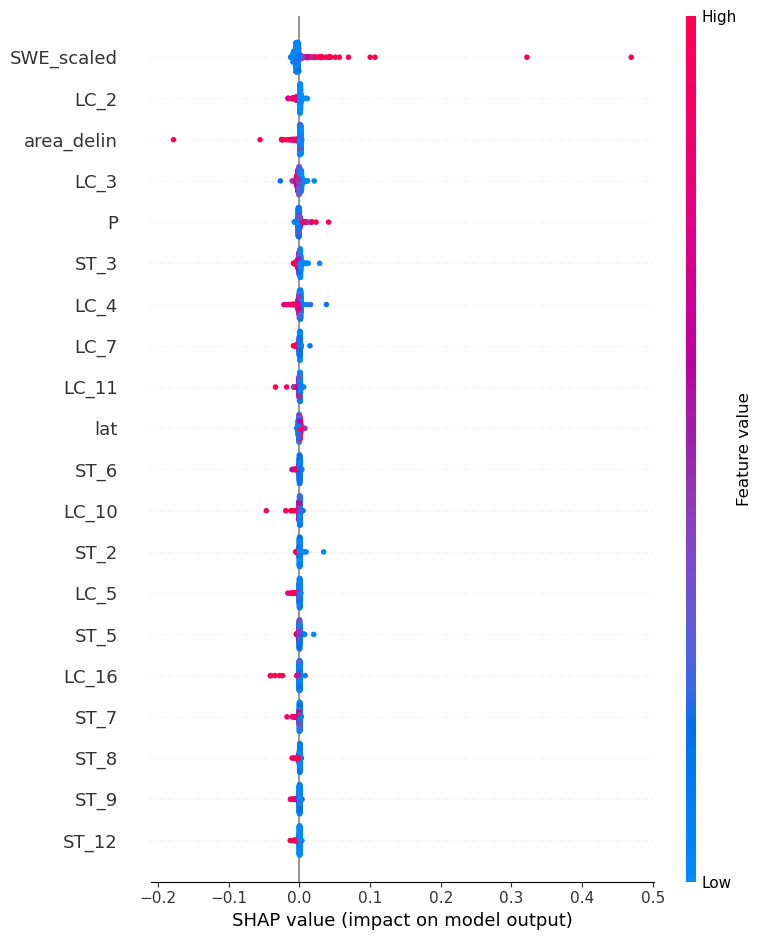

In [33]:
shap_features = ['lat', 'area_delin', 'SWE_scaled', 'P', 'avg_slope', 'max_slope', 'LC_1', 'LC_2', 'LC_3', 'LC_4', 
                 'LC_5', 'LC_6', 'LC_7', 'LC_8', 'LC_9', 'LC_10', 'LC_11', 'LC_12', 'LC_13', 'LC_14', 'LC_15', 
                 'LC_16', 'LC_17', 'LC_18', 'LC_19', 'LC_20', 'ST_1', 'ST_2', 'ST_3', 'ST_4', 'ST_5', 'ST_6', 
                 'ST_7', 'ST_8', 'ST_9', 'ST_10', 'ST_11', 'ST_12', 'ST_13', 'ST_14', 'ST_15', 'ST_16']
shap.summary_plot(shap_values, X_test_subset,feature_names=shap_features)

/tmp/ipykernel_3167591/833960656.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_subset, feature_names=shap_features,plot_type="bar")


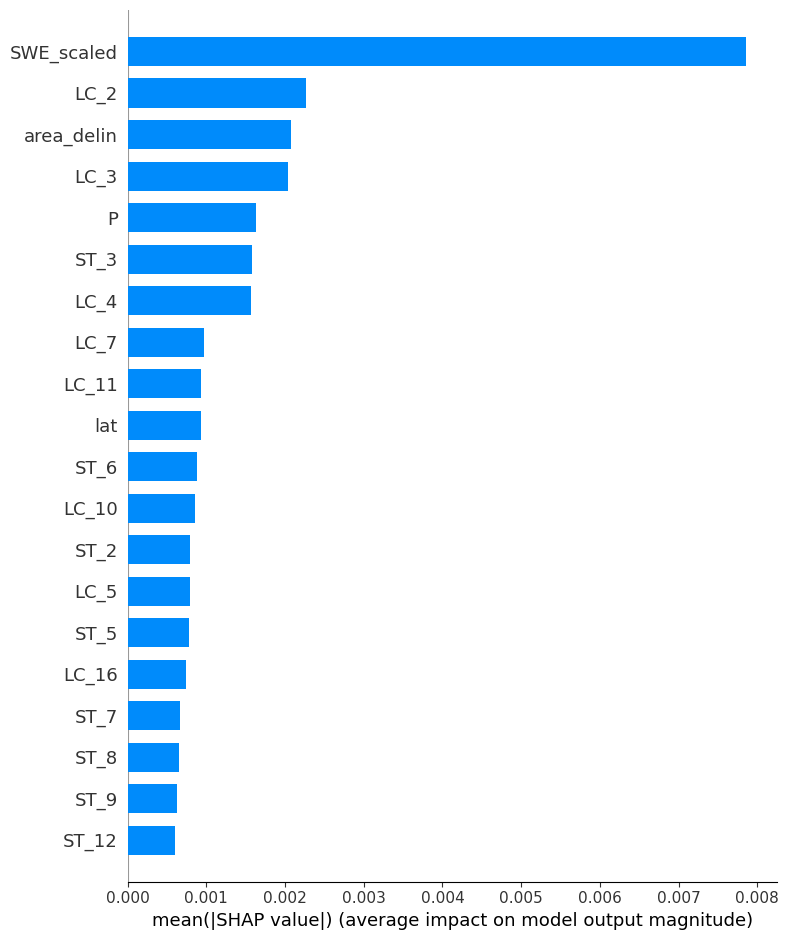

In [34]:
shap.summary_plot(shap_values, X_test_subset, feature_names=shap_features,plot_type="bar")

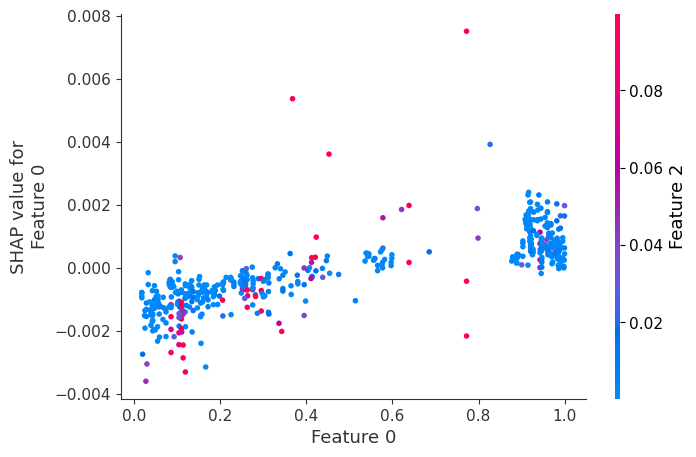

In [35]:
# shap.dependence_plot("Feature 0", shap_values, X_test_subset)
# Fix shape
shap_vals = shap_values.values
if shap_vals.ndim == 3:
    shap_vals = shap_vals[..., 0]

shap.dependence_plot("Feature 0", shap_vals, X_test_subset)

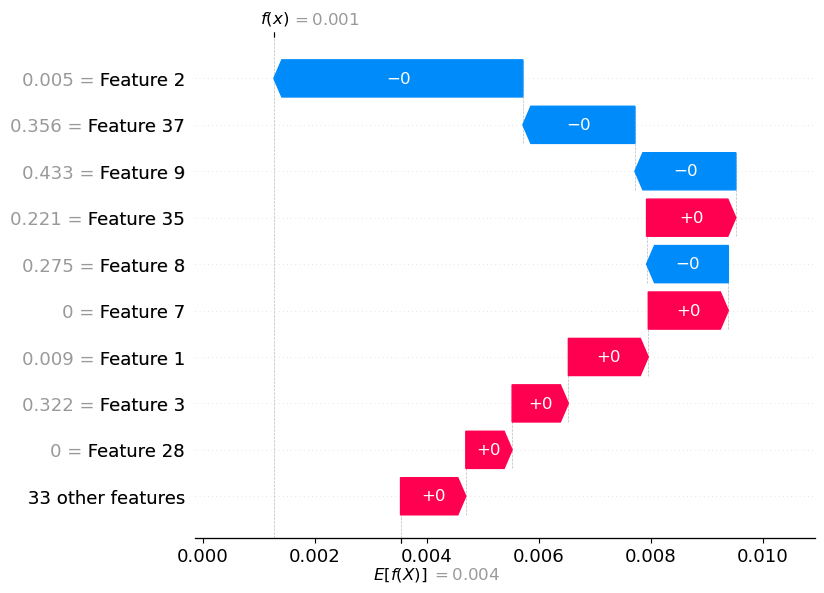

In [36]:
# shap.waterfall_plot(shap_values,X_test_subset)

# pick a random sample index
i = np.random.randint(0, len(X_test_subset))

# pass the single Explanation for that sample
shap.waterfall_plot(shap_values[i])

In [ ]:
# Extract loss and validation loss from the training history
test_values = y_test*max(y)
pred_values = y_pred*max(y)

test_values = np.ravel(test_values)
pred_values = np.ravel(pred_values)

# Create a new DataFrame
pred_df = pd.DataFrame({
    'Test Values': test_values,
    'Predicted Values': pred_values
})

file_path =  '/global/scratch/users/arvalcarcel/CSMUB/RESULTS/CNN/test_vs_pred_values.csv'

# Export to a CSV file
# pred_df.to_csv(file_path, index=False)

from sklearn.metrics import r2_score

# Assuming test_values and pred_values are 1D arrays or lists
r_squared = r2_score(test_values, pred_values)
print(f"R-squared value: {r_squared}")

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# Compute MSE
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error (MSE):", mse)

# Extract loss and validation loss from the training history
training_loss = history.history['loss']
validation_loss = history.history['val_loss']

# Create a new DataFrame
loss_df = pd.DataFrame({
    'Epoch': range(1, len(training_loss) + 1),  # Adding epoch numbers
    'Training Loss': training_loss,
    'Validation Loss': validation_loss
})

file_path =  '/global/scratch/users/arvalcarcel/CSMUB/RESULTS/CNN/training_validation_losses.csv'

# Export to a CSV file
# loss_df.to_csv(file_path, index=False)

In [ ]:
# Plot y_test and y_pred as a time series
plt.figure(figsize=(12, 6))
plt.plot(np.arange(len(y_test)), y_test*max(y), label="Actual Values (y_test)", color="blue", alpha=0.7)
plt.plot(np.arange(len(y_pred)), y_pred*max(y), label="Predicted Values (y_pred)", color="red", alpha=0.7)
plt.title("Actual vs Predicted Values of Test Dataset")
plt.xlabel("Test Dataset")
plt.ylabel("Streamflow [m${^3}$/s]")
plt.xlim(0,len(y_test))
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Plot y_test and y_pred as a time series
plt.figure(figsize=(12, 6))
plt.plot((np.arange(len(y_test)))[0:500], (y_test*max(y))[0:500], label="Actual Values (y_test)", color="blue", alpha=0.7)
plt.plot((np.arange(len(y_pred)))[0:500], (y_pred*max(y))[0:500], label="Predicted Values (y_pred)", color="red", alpha=0.7)

# Add titles and labels
plt.title("Actual vs Predicted Values of Test Dataset (element 0 to 500)")
plt.xlabel("Test Dataset")
plt.ylabel("Streamflow [m${^3}$/s]")
# plt.xlim(0,len(y_test))
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
plt.scatter(scaled,q)
plt.title('Raw Data - All Basins')
plt.xlabel('Surface Water Extent Area [km${^2}$]')
plt.ylabel('Streamflow [m${^3}$/s]')
# plt.savefig('global/scratch/users/arvalcarcel/CSMUB/RESULTS/CNN/rawdata.png')
plt.show()

In [ ]:
plt.scatter(area,q,color='g')
plt.title('Raw Data - All Basins')
plt.xlabel('Total Basin Area [km${^2}$]')
plt.ylabel('Streamflow [m${^3}$/s]')
# plt.savefig('global/scratch/users/arvalcarcel/CSMUB/RESULTS/CNN/rawdata.png')
plt.show()

In [ ]:
plt.scatter(lat*np.pi/180,q,color='r')
plt.title('Raw Data - All Basins')
plt.xlabel('Latitude [deg]')
plt.ylabel('Streamflow [m${^3}$/s]')
# plt.savefig('global/scratch/users/arvalcarcel/CSMUB/RESULTS/CNN/rawdata.png')
plt.show()

In [ ]:
plt.scatter(avg_slope,q,color='purple')
plt.title('Raw Data - All Basins')
plt.xlabel('Slope [deg]')
plt.ylabel('Streamflow [m${^3}$/s]')
# plt.savefig('global/scratch/users/arvalcarcel/CSMUB/RESULTS/CNN/rawdata.png')
plt.show()

In [ ]:
plt.scatter(max_slope,q,color='brown')
plt.title('Raw Data - All Basins')
plt.xlabel('Slope [deg]')
plt.ylabel('Streamflow [m${^3}$/s]')
# plt.savefig('global/scratch/users/arvalcarcel/CSMUB/RESULTS/CNN/rawdata.png')
plt.show()

In [ ]:
plt.scatter(precip/1e6,q,color='blue')
plt.title('Raw Data - All Basins')
plt.xlabel('Precip []')
plt.ylabel('Streamflow [m${^3}$/s]')
# plt.savefig('global/scratch/users/arvalcarcel/CSMUB/RESULTS/CNN/rawdata.png')
plt.show()

In [ ]:
lc_class = lc_types.idxmax(axis=1)
plt.scatter(lc_class,q,color='orange')
plt.title('Raw Data - All Basins')
plt.xlabel('Land Cover Type')
plt.ylabel('Streamflow [m${^3}$/s]')
# plt.savefig('global/scratch/users/arvalcarcel/CSMUB/RESULTS/CNN/rawdata.png')
plt.show()

In [ ]:
soil_class = soil_types.idxmax(axis=1)

plt.scatter(soil_class,q,color='darkorange')
plt.title('Raw Data - All Basins')
plt.xlabel('Soil Texture')
plt.ylabel('Streamflow [m${^3}$/s]')
# plt.savefig('global/scratch/users/arvalcarcel/CSMUB/RESULTS/CNN/rawdata.png')
plt.show()

In [ ]:
grouped = total_df.groupby('Area')['Q'].mean()

# Extract unique areas and their corresponding average Q values
area_unique = grouped.index
q_avg = grouped.values

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(area_unique, q_avg, color='g')
plt.xlabel('Total Basin Area')
plt.ylabel('Average Streamflow')
plt.title('Average Streamflow vs Total Basin Area')
plt.grid(True)
plt.show()

In [ ]:
grouped = total_df.groupby('Latitude')['Q'].mean()

# Extract unique areas and their corresponding average Q values
lat_unique = grouped.index
q_avg = grouped.values

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(lat_unique, q_avg,color='red')
plt.xlabel('Latitude')
plt.ylabel('Average Streamflow')e
plt.title('Average Streamflow vs Basin Latitude')
plt.grid(True)
plt.show()

In [ ]:
filename = '/global/scratch/users/arvalcarcel/CSMUB/RESULTS/CNN/rnn_plot.png'
# Ensure the directory exists
os.makedirs(os.path.dirname(filename), exist_ok=True)
from tensorflow.keras.utils import plot_model

# Plot and save the model
plot_model(model,show_dtype=True, show_layer_names=True, show_shapes=True,  to_file=filename)

# # from IPython.display import Image
# # Image(filename)